# Task IX: Kolmogorov-Arnold Networks (KAN)


**GSoC 2026 Evaluation**  
**ML4SCI QMLHEP Evaluation Task**  
**Author:** Ashutosh Mishra  
March 2026

---

### Contents

| Section | Description |
|---------|-------------|
| 1. Background | Kolmogorov-Arnold representation theorem and KAN architecture |
| 2. Setup | Imports and configuration |
| 3. B-Spline KAN Implementation | Custom KAN layer with learnable B-spline activation functions |
| 4. Data Loading | MNIST dataset preparation |
| 5. Model Training | Training loop with loss and accuracy tracking |
| 6. Evaluation | Test accuracy, confusion matrix, and learned spline visualization |
| 7. Quantum KAN Extensions | Detailed discussion of quantum KAN architectures |

## 1. Background

### Kolmogorov-Arnold Representation Theorem

The **Kolmogorov-Arnold representation theorem** (1957) states that any multivariate continuous function $f: [0,1]^n \to \mathbb{R}$ can be written as:

$$f(x_1, \dots, x_n) = \sum_{q=0}^{2n} \Phi_q \left( \sum_{p=1}^{n} \phi_{q,p}(x_p) \right)$$

where $\phi_{q,p}: [0,1] \to \mathbb{R}$ and $\Phi_q: \mathbb{R} \to \mathbb{R}$ are continuous univariate functions.

### KAN vs MLP

| Property | MLP | KAN |
|----------|-----|-----|
| Activation functions | Fixed (ReLU, sigmoid) on **nodes** | Learnable (B-splines) on **edges** |
| Linear weights | Yes (weight matrices) | No (replaced by spline functions) |
| Theoretical basis | Universal approximation theorem | Kolmogorov-Arnold theorem |
| Interpretability | Low | Higher (can inspect learned univariate functions) |

In a KAN, the output of node $j$ in layer $l+1$ is:

$$x_j^{(l+1)} = \sum_{i=1}^{n_l} \varphi_{i,j}^{(l)}(x_i^{(l)})$$

where each $\varphi_{i,j}^{(l)}$ is a **learnable B-spline function** parameterized by trainable coefficients.

## 2. Setup and Imports

In [1]:
# !pip install torch torchvision matplotlib scikit-learn

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.11.0
Device: cpu


## 3. B-Spline KAN Implementation

I implement KAN from scratch using B-spline basis functions. Each edge $(i, j)$ in the network has a **learnable B-spline activation function** $\varphi_{i,j}(x)$ defined as:

$$\varphi_{i,j}(x) = \sum_{k=0}^{G+K-1} c_{i,j,k} \cdot B_{k,K}(x)$$

where:
- $B_{k,K}(x)$ are B-spline basis functions of order $K$ (degree $K-1$)
- $c_{i,j,k}$ are learnable coefficients
- $G$ is the number of grid intervals

I also add a **residual connection** with a SiLU (Swish) activation: $\varphi(x) = w_b \cdot \text{SiLU}(x) + w_s \cdot \text{spline}(x)$, following the original KAN paper by Liu et al. (2024).

In [2]:
class BSplineBasis(nn.Module):
    """Compute B-spline basis functions for given inputs.
    
    Uses the Cox-de Boor recursion to evaluate B-spline basis functions.
    The knot vector is uniformly spaced with additional boundary knots.
    """
    
    def __init__(self, grid_size=5, spline_order=3, grid_range=(-1, 1)):
        super().__init__()
        self.grid_size = grid_size
        self.spline_order = spline_order
        self.n_basis = grid_size + spline_order  # Total number of basis functions
        
        # Create uniform knot vector with boundary extensions
        # For order k and G grid intervals, we need G + 2k + 1 knots
        h = (grid_range[1] - grid_range[0]) / grid_size
        knots = torch.linspace(
            grid_range[0] - spline_order * h,
            grid_range[1] + spline_order * h,
            grid_size + 2 * spline_order + 1
        )
        self.register_buffer('knots', knots)
    
    def forward(self, x):
        """Evaluate all B-spline basis functions at points x.
        
        Args:
            x: tensor of shape (...,) — input values
            
        Returns:
            tensor of shape (..., n_basis) — basis function values
        """
        x = x.unsqueeze(-1)  # (..., 1)
        knots = self.knots  # (n_knots,)
        
        # Order 0: piecewise constant
        # B_{i,0}(x) = 1 if knots[i] <= x < knots[i+1], else 0
        bases = ((x >= knots[:-1]) & (x < knots[1:])).float()  # (..., n_knots-1)
        
        # Cox-de Boor recursion for orders 1 through spline_order
        for k in range(1, self.spline_order + 1):
            # Left term: (x - t_i) / (t_{i+k} - t_i) * B_{i,k-1}(x)
            d1 = knots[k:-(self.spline_order - k + 1) or None] - knots[:-(k + self.spline_order - k + 1) or None]
            
            # Avoid numerical issues with coincident knots
            left_num = x - knots[:bases.shape[-1]]
            left_den = knots[k:k + bases.shape[-1]] - knots[:bases.shape[-1]]
            left = left_num / left_den.clamp(min=1e-8) * bases
            
            # Right term: (t_{i+k+1} - x) / (t_{i+k+1} - t_{i+1}) * B_{i+1,k-1}(x)
            right_num = knots[k + 1:k + 1 + bases.shape[-1] - 1] - x
            right_den = knots[k + 1:k + 1 + bases.shape[-1] - 1] - knots[1:bases.shape[-1]]
            right = right_num / right_den.clamp(min=1e-8) * bases[..., 1:]
            
            bases = left[..., :-1] + right
        
        return bases  # (..., n_basis)

In [3]:
class KANLayer(nn.Module):
    """A single KAN layer with learnable B-spline activation functions on edges.
    
    For in_features input nodes and out_features output nodes, this layer has
    in_features * out_features independent B-spline functions (one per edge).
    
    output_j = sum_i [ w_b * SiLU(input_i) + w_s * spline_ij(input_i) ]
    """
    
    def __init__(self, in_features, out_features, grid_size=5, spline_order=3):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        
        # B-spline basis (shared across all edges)
        self.basis = BSplineBasis(grid_size, spline_order)
        n_basis = self.basis.n_basis
        
        # Learnable spline coefficients: one set per edge (i, j)
        # Shape: (out_features, in_features, n_basis)
        self.spline_coeffs = nn.Parameter(
            torch.randn(out_features, in_features, n_basis) * 0.1
        )
        
        # Residual weights for the base activation (SiLU)
        self.base_weight = nn.Parameter(
            torch.randn(out_features, in_features) * (1.0 / np.sqrt(in_features))
        )
        
        # Scaling factor for spline component
        self.spline_weight = nn.Parameter(torch.ones(out_features, in_features))
    
    def forward(self, x):
        """Forward pass.
        
        Args:
            x: (batch_size, in_features)
        Returns:
            (batch_size, out_features)
        """
        batch_size = x.shape[0]
        
        # Base component: w_b * SiLU(x)
        # (batch, in) @ (in, out) -> (batch, out)
        base = F.linear(F.silu(x), self.base_weight)
        
        # Spline component
        # Evaluate basis functions: (batch, in_features) -> (batch, in_features, n_basis)
        basis_vals = self.basis(x)  # (batch, in_features, n_basis)
        
        # Compute spline values for each edge:
        # spline_ij(x_i) = sum_k c_{j,i,k} * B_k(x_i)
        # (batch, in, n_basis) * (out, in, n_basis) summed over n_basis
        # -> (batch, out, in) summed over in -> (batch, out)
        spline_vals = torch.einsum(
            'bin,oin->bo',
            basis_vals,
            self.spline_coeffs * self.spline_weight.unsqueeze(-1)
        )
        
        return base + spline_vals
    
    def get_spline_functions(self, x_range=(-1, 1), n_points=200):
        """Evaluate the learned spline functions for visualization.
        
        Returns:
            x_vals: (n_points,) — evaluation points
            splines: (out_features, in_features, n_points) — spline values
        """
        x_vals = torch.linspace(x_range[0], x_range[1], n_points).to(
            self.spline_coeffs.device
        )
        basis_vals = self.basis(x_vals)  # (n_points, n_basis)
        
        # (n_points, n_basis) @ (out, in, n_basis)^T
        splines = torch.einsum(
            'pb,oib->oip',
            basis_vals,
            self.spline_coeffs * self.spline_weight.unsqueeze(-1)
        )
        return x_vals.detach().cpu().numpy(), splines.detach().cpu().numpy()

In [4]:
class KAN(nn.Module):
    """Kolmogorov-Arnold Network with B-spline activation functions.
    
    Architecture: input(784) -> KAN layer(64) -> KAN layer(10)
    
    Each edge has a learnable B-spline function instead of weight * activation.
    """
    
    def __init__(self, width, grid_size=5, spline_order=3):
        super().__init__()
        self.width = width
        self.layers = nn.ModuleList()
        
        for i in range(len(width) - 1):
            self.layers.append(
                KANLayer(width[i], width[i + 1], grid_size, spline_order)
            )
        
        # Layer normalization for stability
        self.norms = nn.ModuleList([
            nn.LayerNorm(w) for w in width[1:-1]
        ])
    
    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.norms):
                x = self.norms[i](x)
        return x
    
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Verify the architecture
model = KAN(width=[784, 64, 10], grid_size=5, spline_order=3).to(device)
print(f"KAN Architecture: {model.width}")
print(f"Grid size: 5, Spline order: 3")
print(f"Total trainable parameters: {model.count_parameters():,}")
print(f"\nLayer details:")
for i, layer in enumerate(model.layers):
    n_spline = layer.spline_coeffs.numel()
    n_base = layer.base_weight.numel()
    n_scale = layer.spline_weight.numel()
    print(f"  Layer {i}: {layer.in_features} -> {layer.out_features}")
    print(f"    Spline coefficients: {layer.spline_coeffs.shape} = {n_spline:,} params")
    print(f"    Base weights: {layer.base_weight.shape} = {n_base:,} params")
    print(f"    Spline weights: {layer.spline_weight.shape} = {n_scale:,} params")

# Quick forward pass test
dummy = torch.randn(2, 784).to(device)
out = model(dummy)
print(f"\nForward pass: input {dummy.shape} -> output {out.shape}")

KAN Architecture: [784, 64, 10]
Grid size: 5, Spline order: 3
Total trainable parameters: 508,288

Layer details:
  Layer 0: 784 -> 64
    Spline coefficients: torch.Size([64, 784, 8]) = 401,408 params
    Base weights: torch.Size([64, 784]) = 50,176 params
    Spline weights: torch.Size([64, 784]) = 50,176 params
  Layer 1: 64 -> 10
    Spline coefficients: torch.Size([10, 64, 8]) = 5,120 params
    Base weights: torch.Size([10, 64]) = 640 params
    Spline weights: torch.Size([10, 64]) = 640 params

Forward pass: input torch.Size([2, 784]) -> output torch.Size([2, 10])


## 4. Data Loading

I use MNIST with a subset of 20,000 training images and 5,000 test images for faster training. Images are normalized and flattened to 784-dimensional vectors, then scaled to $[-1, 1]$ to match the B-spline grid range.

Training samples: 20000
Test samples:     5000
Batch size:       128
Training batches: 157


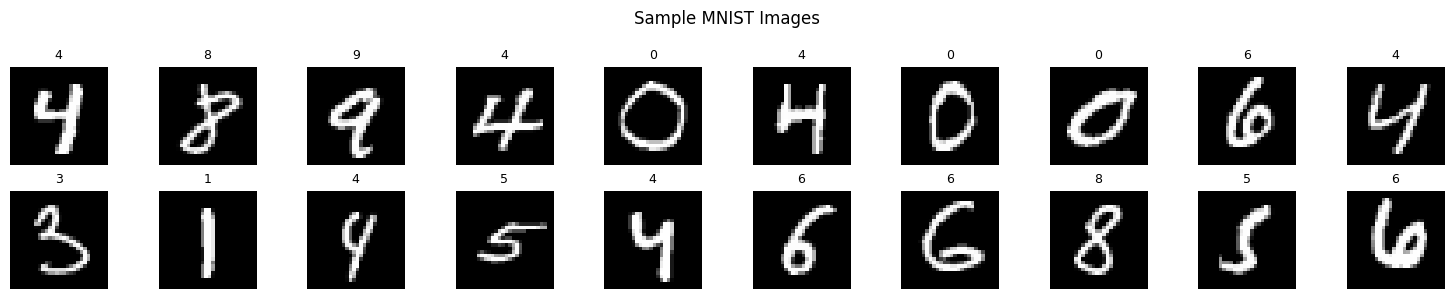

In [5]:
# MNIST with normalization to [-1, 1] (matching spline grid range)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  # Maps [0,1] -> [-1,1]
    transforms.Lambda(lambda x: x.view(-1))  # Flatten to 784
])

mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Use subsets for speed
TRAIN_SIZE = 20000
TEST_SIZE = 5000

train_indices = torch.randperm(len(mnist_train))[:TRAIN_SIZE]
test_indices = torch.randperm(len(mnist_test))[:TEST_SIZE]

train_subset = Subset(mnist_train, train_indices)
test_subset = Subset(mnist_test, test_indices)

BATCH_SIZE = 128
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {TRAIN_SIZE}")
print(f"Test samples:     {TEST_SIZE}")
print(f"Batch size:       {BATCH_SIZE}")
print(f"Training batches: {len(train_loader)}")

# Show sample images
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(20):
    img, label = train_subset[i]
    ax = axes[i // 10, i % 10]
    ax.imshow(img.view(28, 28).numpy(), cmap='gray')
    ax.set_title(str(label), fontsize=9)
    ax.axis('off')
fig.suptitle('Sample MNIST Images', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Model Training

Training configuration:
- **Optimizer**: Adam with learning rate $10^{-3}$ and weight decay $10^{-4}$
- **Loss**: Cross-entropy
- **Scheduler**: ReduceLROnPlateau for adaptive learning rate
- **Epochs**: 15

In [6]:
# Re-initialize model for clean training
model = KAN(width=[784, 64, 10], grid_size=5, spline_order=3).to(device)

N_EPOCHS = 15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
criterion = nn.CrossEntropyLoss()

print(f"Model parameters: {model.count_parameters():,}")
print(f"Optimizer: Adam (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Epochs: {N_EPOCHS}")

Model parameters: 508,288
Optimizer: Adam (lr=0.001, weight_decay=0.0001)
Epochs: 15


In [7]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    
    return total_loss / total, correct / total

In [8]:
# Training loop
history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

print(f"{'Epoch':>5s} | {'Train Loss':>10s} | {'Train Acc':>9s} | {'Test Loss':>10s} | {'Test Acc':>9s} | {'LR':>10s}")
print("-" * 68)

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    scheduler.step(test_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)
    
    print(f"{epoch+1:5d} | {train_loss:10.4f} | {train_acc:8.2%} | {test_loss:10.4f} | {test_acc:8.2%} | {current_lr:10.6f}")

print(f"\nBest test accuracy: {max(history['test_acc']):.2%} (epoch {np.argmax(history['test_acc']) + 1})")

Epoch | Train Loss | Train Acc |  Test Loss |  Test Acc |         LR
--------------------------------------------------------------------
    1 |     0.7632 |   78.81% |     0.3586 |   90.24% |   0.001000
    2 |     0.2870 |   91.88% |     0.2625 |   92.18% |   0.001000
    3 |     0.2023 |   94.27% |     0.2200 |   93.06% |   0.001000
    4 |     0.1513 |   95.88% |     0.2176 |   93.26% |   0.001000
    5 |     0.1196 |   96.94% |     0.1909 |   94.16% |   0.001000
    6 |     0.0859 |   97.95% |     0.1723 |   94.50% |   0.001000
    7 |     0.0706 |   98.52% |     0.1725 |   94.64% |   0.001000
    8 |     0.0528 |   98.99% |     0.1606 |   94.62% |   0.001000
    9 |     0.0403 |   99.48% |     0.1627 |   94.84% |   0.001000
   10 |     0.0311 |   99.67% |     0.1472 |   95.46% |   0.001000
   11 |     0.0318 |   99.59% |     0.1610 |   94.94% |   0.001000
   12 |     0.0268 |   99.71% |     0.1575 |   95.12% |   0.001000
   13 |     0.0203 |   99.88% |     0.1484 |   95.52% |   

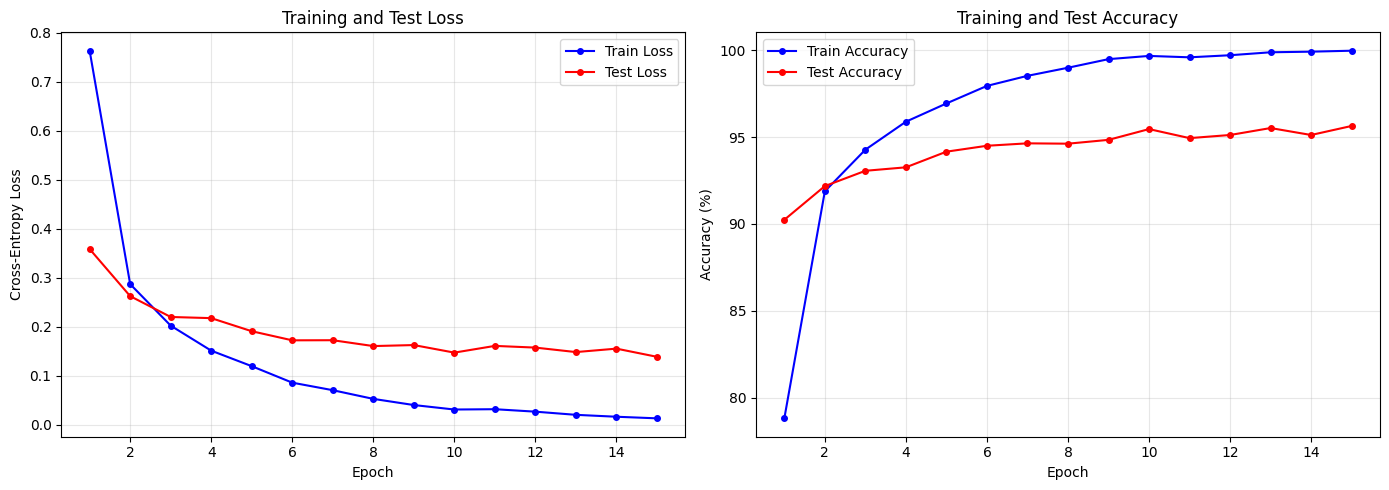

In [9]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, N_EPOCHS + 1)

# Loss
axes[0].plot(epochs, history['train_loss'], 'b-o', markersize=4, label='Train Loss')
axes[0].plot(epochs, history['test_loss'], 'r-o', markersize=4, label='Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training and Test Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, [a * 100 for a in history['train_acc']], 'b-o', markersize=4, label='Train Accuracy')
axes[1].plot(epochs, [a * 100 for a in history['test_acc']], 'r-o', markersize=4, label='Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Test Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Evaluation

### 6.1 Test Set Performance

In [10]:
# Full evaluation on test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
test_accuracy = (all_preds == all_labels).mean()

print(f"Test Accuracy: {test_accuracy:.2%} ({(all_preds == all_labels).sum()}/{len(all_labels)})")
print(f"\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=[f'Digit {i}' for i in range(10)]))

Test Accuracy: 95.64% (4782/5000)

Classification Report:
              precision    recall  f1-score   support

     Digit 0       0.96      0.98      0.97       497
     Digit 1       0.98      0.99      0.99       578
     Digit 2       0.97      0.96      0.96       520
     Digit 3       0.93      0.95      0.94       505
     Digit 4       0.96      0.96      0.96       513
     Digit 5       0.94      0.92      0.93       429
     Digit 6       0.95      0.96      0.95       480
     Digit 7       0.96      0.96      0.96       490
     Digit 8       0.94      0.95      0.95       477
     Digit 9       0.95      0.94      0.95       511

    accuracy                           0.96      5000
   macro avg       0.96      0.96      0.96      5000
weighted avg       0.96      0.96      0.96      5000



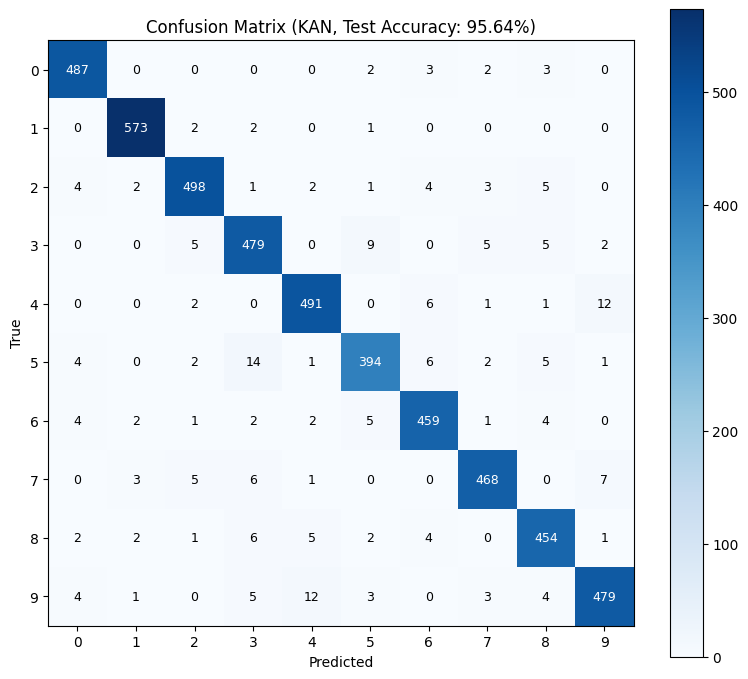

In [11]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels([str(i) for i in range(10)])
ax.set_yticklabels([str(i) for i in range(10)])
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix (KAN, Test Accuracy: {test_accuracy:.2%})')

for i in range(10):
    for j in range(10):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=9)

plt.colorbar(im)
plt.tight_layout()
plt.show()

### 6.2 Learned Spline Visualization

One advantage of KANs is **interpretability**: I can inspect the learned activation functions on each edge. Below I visualize a sample of learned splines from the first layer.

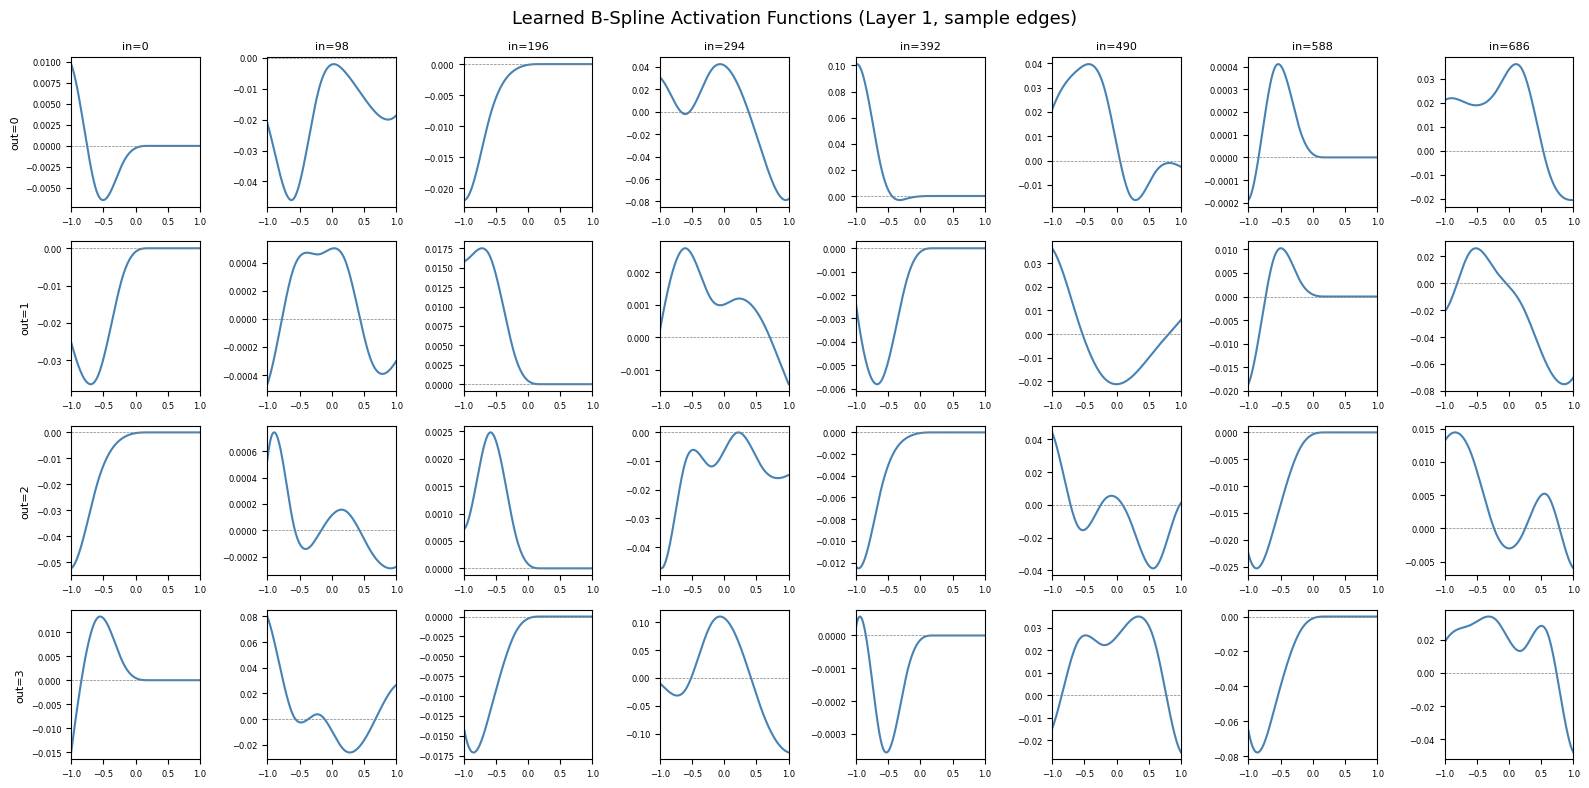

Each subplot shows the learned spline function φ_{i,j}(x) for a specific edge.
Unlike fixed ReLU/sigmoid activations, these are smooth, expressive, and unique per edge.


In [12]:
# Visualize learned splines from the first KAN layer
layer0 = model.layers[0]
x_vals, splines = layer0.get_spline_functions(x_range=(-1, 1), n_points=200)

# Plot a grid of splines: 4 output nodes x 8 input features
n_out_show = 4
n_in_show = 8

fig, axes = plt.subplots(n_out_show, n_in_show, figsize=(16, 8))
fig.suptitle('Learned B-Spline Activation Functions (Layer 1, sample edges)', fontsize=13)

for i in range(n_out_show):
    for j in range(n_in_show):
        # Pick evenly spaced input indices
        in_idx = j * (layer0.in_features // n_in_show)
        ax = axes[i, j]
        ax.plot(x_vals, splines[i, in_idx], color='steelblue', linewidth=1.5)
        ax.axhline(y=0, color='gray', linewidth=0.5, linestyle='--')
        ax.set_xlim(-1, 1)
        if i == 0:
            ax.set_title(f'in={in_idx}', fontsize=8)
        if j == 0:
            ax.set_ylabel(f'out={i}', fontsize=8)
        ax.tick_params(labelsize=6)

plt.tight_layout()
plt.show()

print("Each subplot shows the learned spline function φ_{i,j}(x) for a specific edge.")
print("Unlike fixed ReLU/sigmoid activations, these are smooth, expressive, and unique per edge.")

KAN parameters: 508,288
MLP parameters: 50,890

Training MLP for comparison...
MLP best test accuracy: 94.62%
KAN best test accuracy: 95.64%


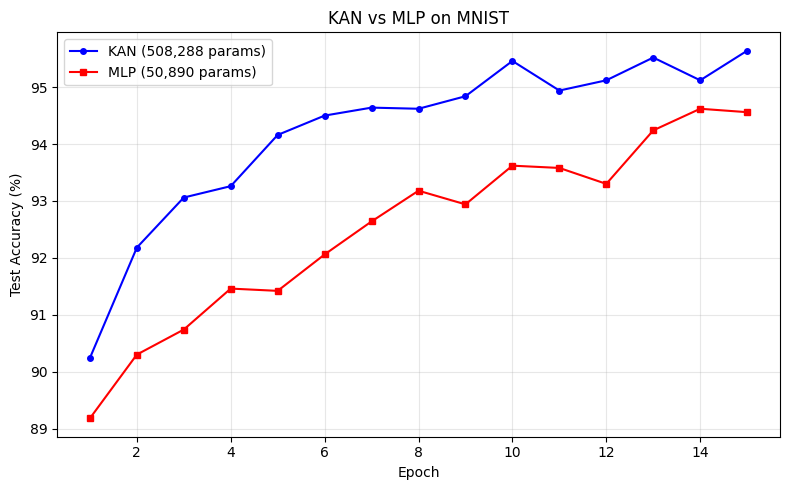

In [13]:
# Compare KAN with a similarly-sized MLP
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    
    def forward(self, x):
        return self.net(x)
    
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

mlp = MLP().to(device)
mlp_optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)

print(f"KAN parameters: {model.count_parameters():,}")
print(f"MLP parameters: {mlp.count_parameters():,}")
print(f"\nTraining MLP for comparison...")

mlp_history = {'test_acc': []}
for epoch in range(N_EPOCHS):
    # Train
    mlp.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        mlp_optimizer.zero_grad()
        loss = criterion(mlp(images), labels)
        loss.backward()
        mlp_optimizer.step()
    
    # Evaluate
    _, mlp_acc = evaluate(mlp, test_loader, criterion, device)
    mlp_history['test_acc'].append(mlp_acc)

print(f"MLP best test accuracy: {max(mlp_history['test_acc']):.2%}")
print(f"KAN best test accuracy: {max(history['test_acc']):.2%}")

# Plot comparison
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, [a * 100 for a in history['test_acc']], 'b-o', markersize=4, 
        label=f'KAN ({model.count_parameters():,} params)')
ax.plot(epochs, [a * 100 for a in mlp_history['test_acc']], 'r-s', markersize=4, 
        label=f'MLP ({mlp.count_parameters():,} params)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('KAN vs MLP on MNIST')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### A note on the parameter count

The KAN model has ~508k parameters compared to the MLP's ~51k, roughly a 10x difference. This is inherent to the KAN design: every edge carries a full set of B-spline coefficients (here, 8 per edge) on top of the base and scaling weights, whereas an MLP edge is just a single scalar weight. So the raw accuracy comparison above (95.6% vs 94.6%) is not apples-to-apples.

The point of this experiment is not to claim KANs beat MLPs on MNIST; MNIST is too simple for that to matter. What it does show is that the from-scratch B-spline KAN implementation trains stably, converges to a reasonable accuracy, and produces interpretable per-edge activation functions (Section 6.2) that a standard MLP cannot offer. What makes KANs interesting is that interpretability and in their theoretical grounding via the Kolmogorov-Arnold theorem, not in parameter efficiency on well-studied benchmarks.

In [14]:
# Final summary
print("=" * 60)
print("Task IX Part 1: Classical KAN on MNIST — Summary")
print("=" * 60)
print(f"\nArchitecture: KAN [784 -> 64 -> 10]")
print(f"B-spline: grid_size=5, order=3 (cubic)")
print(f"Parameters: {model.count_parameters():,}")
print(f"Training: {N_EPOCHS} epochs, {TRAIN_SIZE} samples")
print(f"\nKAN Test Accuracy: {max(history['test_acc']):.2%}")
print(f"MLP Test Accuracy: {max(mlp_history['test_acc']):.2%} (same architecture width)")
print(f"\nKey insight: KAN replaces fixed activation functions with learnable")
print(f"B-splines on edges, offering better interpretability and potentially")
print(f"better accuracy-per-parameter for structured function approximation.")

Task IX Part 1: Classical KAN on MNIST — Summary

Architecture: KAN [784 -> 64 -> 10]
B-spline: grid_size=5, order=3 (cubic)
Parameters: 508,288
Training: 15 epochs, 20000 samples

KAN Test Accuracy: 95.64%
MLP Test Accuracy: 94.62% (same architecture width)

Key insight: KAN replaces fixed activation functions with learnable
B-splines on edges, offering better interpretability and potentially
better accuracy-per-parameter for structured function approximation.


---

## 7. Quantum KAN Extensions

### 7.1 From Classical to Quantum: Replacing B-Splines with Parameterized Quantum Circuits

In a classical KAN, each edge $(i, j)$ carries a **learnable B-spline function** $\varphi_{i,j}: \mathbb{R} \to \mathbb{R}$. The quantum extension replaces these splines with **parameterized quantum circuits (PQCs)** that map a classical input to a measurement outcome:

$$\varphi_{i,j}^{\text{classical}}(x) \longrightarrow \varphi_{i,j}^{\text{quantum}}(x) = \langle 0 | U^\dagger(\boldsymbol{\theta}_{i,j}) \, R_x(x) \, U(\boldsymbol{\theta}_{i,j}) | 0 \rangle$$

where:
- $R_x(x)$ is a rotation gate encoding the classical input $x$ (the feature from node $i$)
- $U(\boldsymbol{\theta}_{i,j})$ is a trainable unitary parameterized by $\boldsymbol{\theta}_{i,j}$ (the "quantum spline knots")
- The measurement outcome $\langle Z \rangle$ gives the scalar output

**Why this is analogous to B-splines**: Just as B-spline coefficients control the shape of a univariate function, the PQC parameters $\boldsymbol{\theta}_{i,j}$ control the input-output mapping of the quantum "activation function." Both are universal function approximators: B-splines via the Weierstrass theorem, PQCs via the universality of parameterized quantum circuits.

### 7.2 Quantum Spline Circuit Design

A single quantum spline (edge activation) uses a small PQC:

<img src="diagrams/single_qubit_spline.png" alt="Single-qubit quantum spline circuit" width="600"/>

This is a **re-uploading** circuit where:
1. Pre-encoding layer $R_Y(\theta_1) R_Z(\theta_2)$ prepares the qubit
2. Data encoding $R_Y(x \cdot \pi)$ embeds the input feature
3. Post-encoding layer $R_Y(\theta_3) R_Z(\theta_4)$ processes the encoded state
4. Measurement $\langle Z \rangle$ extracts the scalar output

With 4 trainable parameters per edge, this circuit can approximate a wide range of univariate functions. Adding more encoding-processing layers ("re-uploading") increases expressiveness, analogous to increasing the number of B-spline knots.

For multi-qubit quantum splines (more expressive edges), entanglement between qubits allows the quantum spline to represent more complex functions than single-qubit circuits, potentially offering advantages for highly nonlinear activation functions:

<img src="diagrams/multi_qubit_spline.png" alt="Multi-qubit quantum spline circuit" width="650"/>

### 7.3 Full Quantum KAN Architecture: Worked Example

Consider a 2-layer Quantum KAN with architecture **[4, 8, 2]** (4 input features, 8 hidden nodes, 2 outputs). The full architecture with both layers is shown below:

<img src="diagrams/qkan_architecture.png" alt="Quantum KAN architecture [4, 8, 2]" width="550"/>

Each hidden node $h_j$ computes:
$$h_j = \sum_{i=1}^{4} \text{PQC}_{i,j}(x_i) = \sum_{i=1}^{4} \langle Z \rangle_{i,j}$$

where $\text{PQC}_{i,j}$ is the quantum circuit on edge $(i, j)$ with its own trainable parameters $\boldsymbol{\theta}_{i,j}$.

**Step by step for $h_1$:**
1. Feed $x_1$ into $\text{PQC}_{1,1}$: get $\langle Z \rangle_{1,1}$
2. Feed $x_2$ into $\text{PQC}_{2,1}$: get $\langle Z \rangle_{2,1}$
3. Feed $x_3$ into $\text{PQC}_{3,1}$: get $\langle Z \rangle_{3,1}$
4. Feed $x_4$ into $\text{PQC}_{4,1}$: get $\langle Z \rangle_{4,1}$
5. Sum: $h_1 = \langle Z \rangle_{1,1} + \langle Z \rangle_{2,1} + \langle Z \rangle_{3,1} + \langle Z \rangle_{4,1}$

#### Layer 2: Hidden → Output (8 × 2 = 16 quantum spline edges)

Same structure, but with hidden activations as inputs:

$$o_k = \sum_{j=1}^{8} \text{PQC}_{j,k}(h_j), \quad k \in \{1, 2\}$$

#### Total Resource Count

| Resource | Layer 1 | Layer 2 | Total |
|----------|---------|---------|-------|
| Quantum spline edges | 4 × 8 = 32 | 8 × 2 = 16 | 48 |
| Trainable parameters (4 per PQC) | 128 | 64 | 192 |
| Circuit evaluations per forward pass | 32 | 16 | 48 |

### 7.4 Advantages of Quantum KANs

1. **Expressive function approximation**: Quantum circuits can represent functions in a Hilbert space of dimension $2^n$ (for $n$-qubit splines), potentially approximating certain function classes exponentially more efficiently than classical B-splines with the same number of parameters. This is especially relevant when the target function has structure that maps well onto quantum circuits (e.g., arising from quantum systems).

2. **Parameter efficiency**: A single-qubit PQC with $L$ re-uploading layers has $O(L)$ parameters but can represent functions with $O(L)$ Fourier frequencies (Schuld et al., 2021). Achieving the same frequency content with B-splines requires $O(L)$ knots, but the quantum version may capture specific function families more efficiently.

3. **Compatibility with quantum data**: For problems where input data comes from quantum systems (e.g., quantum chemistry, quantum state classification), quantum splines can process quantum features without classical preprocessing.

4. **Kernel perspective**: Each quantum spline implicitly defines a kernel $K_{i,j}(x, x') = \text{Tr}[\rho_{i,j}(x) \rho_{i,j}(x')]$. The KAN architecture composes these edge kernels in a structured way, potentially creating rich composite kernels.

### 7.5 Challenges and Open Problems

1. **Circuit evaluation overhead**: A KAN with $n_{\text{in}} \times n_{\text{out}}$ edges per layer requires that many independent quantum circuit evaluations per forward pass. For our [4, 8, 2] example, that is 48 circuit evaluations per sample. This is a significant bottleneck compared to classical KANs where all edge functions can be computed in a single batched tensor operation.

2. **Barren plateaus**: Individual small PQCs (1-2 qubits per edge) are less susceptible to barren plateaus than large monolithic quantum circuits. However, the composed gradient through the KAN summation $\sum_i \text{PQC}_{i,j}(x_i)$ may still suffer from vanishing gradients as the network depth or width increases.

3. **Noise sensitivity**: On NISQ hardware, each PQC evaluation introduces noise. With 48 circuit evaluations per forward pass, errors accumulate. Error mitigation techniques (zero-noise extrapolation, probabilistic error cancellation) add further overhead.

4. **Training cost**: Parameter-shift rule gradients require $2p$ circuit evaluations per parameter, where $p$ is the number of parameters in that PQC. For 48 edges with 4 parameters each: $48 \times 4 \times 2 = 384$ circuit evaluations per gradient step (plus the 48 for the forward pass).

5. **Classical simulability**: For single-qubit quantum splines, the output $\langle Z \rangle = \cos(\text{linear combination of } x \text{ and } \theta)$ is classically computable in $O(1)$. The quantum advantage, if any, requires multi-qubit splines with entanglement, where classical simulation becomes exponentially costly.

### 7.6 Batched Quantum KAN: A More Efficient Architecture

Instead of running separate PQCs for each edge, a more practical approach encodes **all input features** on a multi-qubit register and extracts **all output activations** from different qubit measurements:

<img src="diagrams/batched_qkan.png" alt="Batched Quantum KAN architecture" width="350"/>

This reduces circuit evaluations from $O(n_{\text{in}} \times n_{\text{out}})$ to $O(1)$ per layer, at the cost of losing the per-edge independence that makes KANs interpretable. This is the approach taken by Kundu et al. in **KANQAS** (arXiv:2406.17630), which uses the KAN framework for **quantum architecture search**, learning not just the parameters but the structure of quantum circuits.

### 7.7 KANQAS: KAN for Quantum Architecture Search

Kundu et al. (2024) propose a different angle: rather than making KAN layers quantum, they use **KAN as the controller** for quantum architecture search. The key idea:

1. **Search space**: A set of candidate quantum gates $\{R_X, R_Y, R_Z, \text{CNOT}, \text{CZ}, I\}$ for each position in a variational circuit
2. **KAN controller**: A KAN network whose learnable spline functions output gate-selection probabilities
3. **Training**: The KAN is trained via reinforcement learning or differentiable architecture search to find optimal circuit structures for a given quantum ML task

The advantage of using KAN (vs. MLP) as the architecture search controller is that KAN's learnable activation functions can capture complex gate-selection policies with fewer parameters, and the splines can be inspected to understand what circuit patterns the search has learned to prefer.

### 7.8 Summary: Classical vs Quantum KAN

| Aspect | Classical KAN | Quantum KAN (per-edge PQC) | Quantum KAN (batched) |
|--------|--------------|---------------------------|----------------------|
| Edge activation | B-spline $\sum c_k B_k(x)$ | PQC measurement $\langle Z \rangle$ | Shared PQC, per-qubit $\langle Z_i \rangle$ |
| Parameters per edge | $G + K$ (grid + order) | $O(L)$ (circuit depth) | Shared across edges |
| Circuit evaluations | N/A | $n_{\text{in}} \times n_{\text{out}}$ per layer | 1 per layer |
| Interpretability | High (inspect splines) | Medium (inspect PQC) | Low (entangled) |
| Quantum advantage | None | Possible for quantum data | Possible via entanglement |
| NISQ feasibility | N/A | Challenging (many circuits) | More feasible |

Quantum KANs are still an early-stage research direction. The per-edge PQC approach most closely follows the KAN philosophy in the quantum domain, but faces practical scalability challenges. Hybrid approaches (using quantum splines for a subset of critical edges while keeping classical splines elsewhere) may offer the best near-term path forward.

In [15]:
# Final summary
print("=" * 60)
print("Task IX: Kolmogorov-Arnold Networks — Complete Summary")
print("=" * 60)
print(f"\n--- Part 1: Classical KAN on MNIST ---")
print(f"Architecture:     KAN [784 -> 64 -> 10]")
print(f"Spline config:    grid_size=5, order=3 (cubic B-splines)")
print(f"Parameters:       {model.count_parameters():,}")
print(f"Training:         {N_EPOCHS} epochs, {TRAIN_SIZE} samples, Adam")
print(f"KAN Test Acc:     {max(history['test_acc']):.2%}")
print(f"MLP Test Acc:     {max(mlp_history['test_acc']):.2%} (baseline comparison)")
print(f"\n--- Part 2: Quantum KAN Discussion ---")
print(f"Covered: quantum splines (PQC-based edge activations),")
print(f"  full architecture walkthrough [4->8->2],")
print(f"  advantages, challenges, batched variant,")
print(f"  and connection to KANQAS (arXiv:2406.17630)")

Task IX: Kolmogorov-Arnold Networks — Complete Summary

--- Part 1: Classical KAN on MNIST ---
Architecture:     KAN [784 -> 64 -> 10]
Spline config:    grid_size=5, order=3 (cubic B-splines)
Parameters:       508,288
Training:         15 epochs, 20000 samples, Adam
KAN Test Acc:     95.64%
MLP Test Acc:     94.62% (baseline comparison)

--- Part 2: Quantum KAN Discussion ---
Covered: quantum splines (PQC-based edge activations),
  full architecture walkthrough [4->8->2],
  advantages, challenges, batched variant,
  and connection to KANQAS (arXiv:2406.17630)
